In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('ggplot')

In [2]:
df = pd.read_excel("../data/clean_fashion_brands.xlsx")

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (101, 12)

Columns:
['Brand', 'Category', 'Country', 'Followers_Million', 'Engagement_Rate', 'Avg_Price_USD', 'Sustainability', 'Target_Audience', 'Global_Stores', 'Trend_Score', 'Collaboration_Count', 'Collaboration_Score']


In [4]:
category_count = df["Category"].value_counts()

category_count

Category
Premium         17
Casual          16
Luxury          16
Sportswear      15
Fast Fashion    13
Streetwear       6
Outdoor          6
Footwear         5
Surfwear         3
Formal           3
Ethnic           1
Name: count, dtype: int64

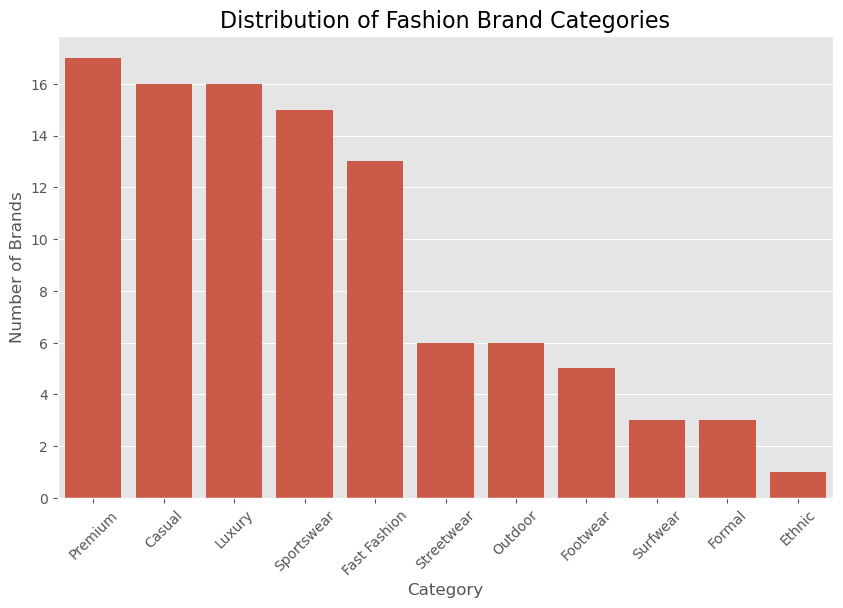

In [5]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.title("Distribution of Fashion Brand Categories", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Number of Brands")

plt.xticks(rotation=45)

plt.show()

# Business Insight

• Sportswear and Luxury brands represent a significant portion of the dataset.
• Fast Fashion also has a strong market presence.
• Categories with fewer brands may indicate niche markets with collaboration opportunities.

# Country-wise Brand Distribution

In [6]:
country_count = df["Country"].value_counts()

country_count

Country
USA            37
Italy          11
UK             11
France         10
Spain           9
Germany         4
Australia       3
Denmark         3
Canada          2
India           2
Japan           2
Sweden          2
South Korea     1
Ireland         1
Switzerland     1
Hong Kong       1
China           1
Name: count, dtype: int64

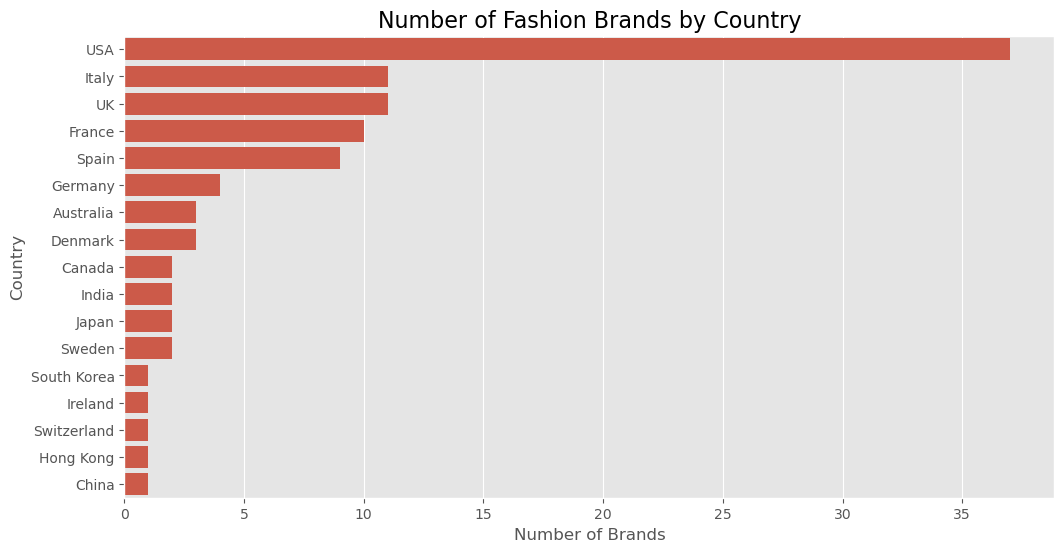

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Country",
    order=df["Country"].value_counts().index
)

plt.title("Number of Fashion Brands by Country", fontsize=16)
plt.xlabel("Number of Brands")
plt.ylabel("Country")

plt.show()

# Business Insight

• The USA has the highest number of brands in the dataset.
• Italy and France dominate the luxury fashion industry.
• Spain contributes strongly through fast-fashion brands.

# Followers Distribution

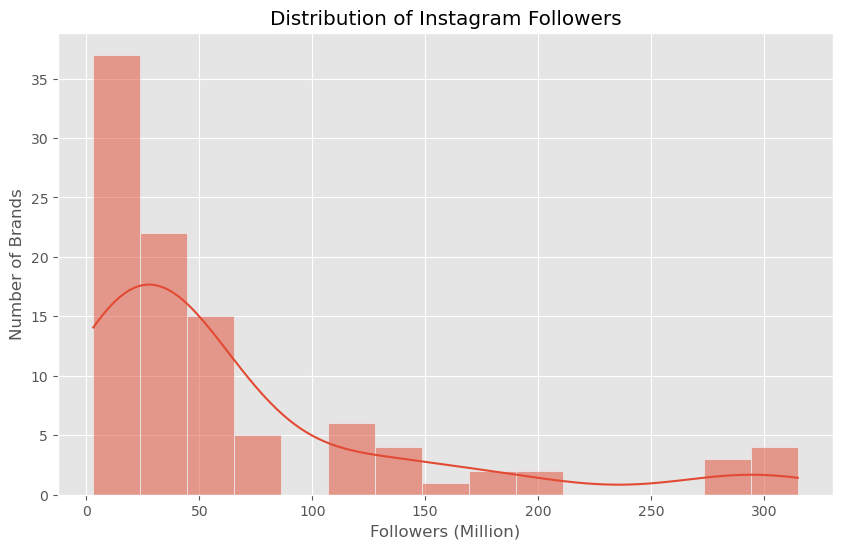

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Followers_Million"],
    bins=15,
    kde=True
)

plt.title("Distribution of Instagram Followers")
plt.xlabel("Followers (Million)")
plt.ylabel("Number of Brands")

plt.show()

# Business Insight

• Most brands have moderate follower counts.
• A few brands have extremely high followers, making them market leaders.
• This indicates an uneven distribution of social media influence.

# Top 10 Brands by Followers

In [9]:
top10 = df.sort_values(
    by="Followers_Million",
    ascending=False
).head(10)

top10

,Brand,Category,Country,Followers_Million,Engagement_Rate,Avg_Price_USD,Sustainability,Target_Audience,Global_Stores,Trend_Score,Collaboration_Count,Collaboration_Score
75,Marks & Spencer,Premium,UK,315,1.31,110,High,Teens,4367,77,19,NaN
17,Calvin Klein,Premium,USA,307,1.95,104,Medium,Teens,2538,86,11,NaN
62,Lululemon,Sportswear,Canada,304,2.11,96,High,Adults,1819,91,21,NaN
92,Ted Baker,Premium,UK,301,1.61,80,Low,Young Adults,2594,95,19,NaN
16,Under Armour,Sportswear,USA,285,1.44,177,Low,Teens,341,81,11,NaN
55,Kate Spade,Premium,USA,277,2.54,125,Medium,Young Adults,865,74,10,NaN
54,DKNY,Premium,USA,274,1.52,130,High,Teens,4164,77,14,NaN
19,Lacoste,Premium,France,210,2.15,81,Medium,Teens,4299,87,10,NaN
64,Decathlon,Sportswear,France,192,2.88,141,Low,Adults,3813,96,4,NaN
15,New Balance,Sportswear,USA,184,1.71,122,High,Adults,2964,92,6,NaN


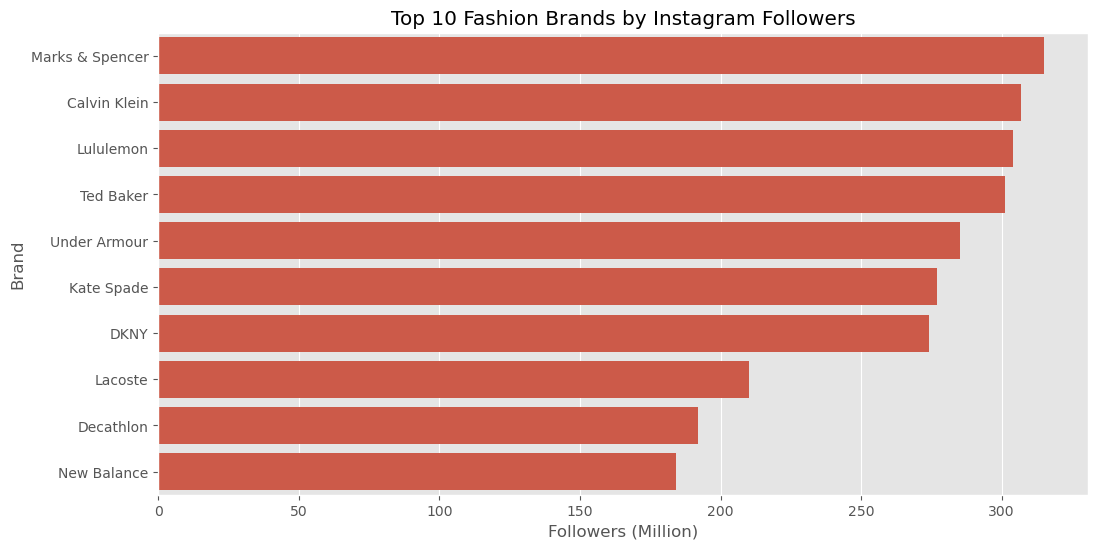

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Followers_Million",
    y="Brand"
)

plt.title("Top 10 Fashion Brands by Instagram Followers")
plt.xlabel("Followers (Million)")
plt.ylabel("Brand")

plt.show()

# Business Insight

• Brands with higher social media reach have greater marketing potential.
• These brands are attractive collaboration partners because of their visibility.

# Trend Score Distribution

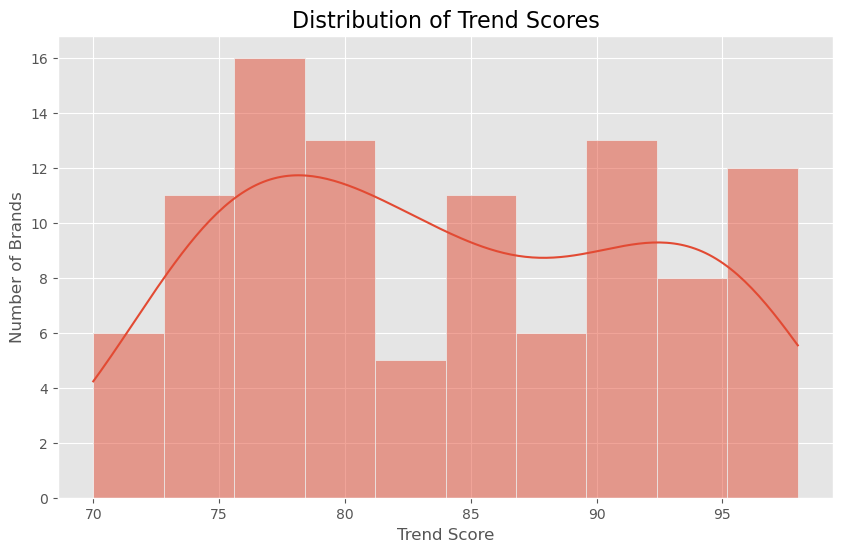

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Trend_Score",
    bins=10,
    kde=True
)

plt.title("Distribution of Trend Scores", fontsize=16)
plt.xlabel("Trend Score")
plt.ylabel("Number of Brands")

plt.show()

 # Business Insight

• Most brands have trend scores between 75 and 95.
• Only a few brands have extremely high trend scores.
• Highly trending brands are strong candidates for collaborations.

# Average Price by Category

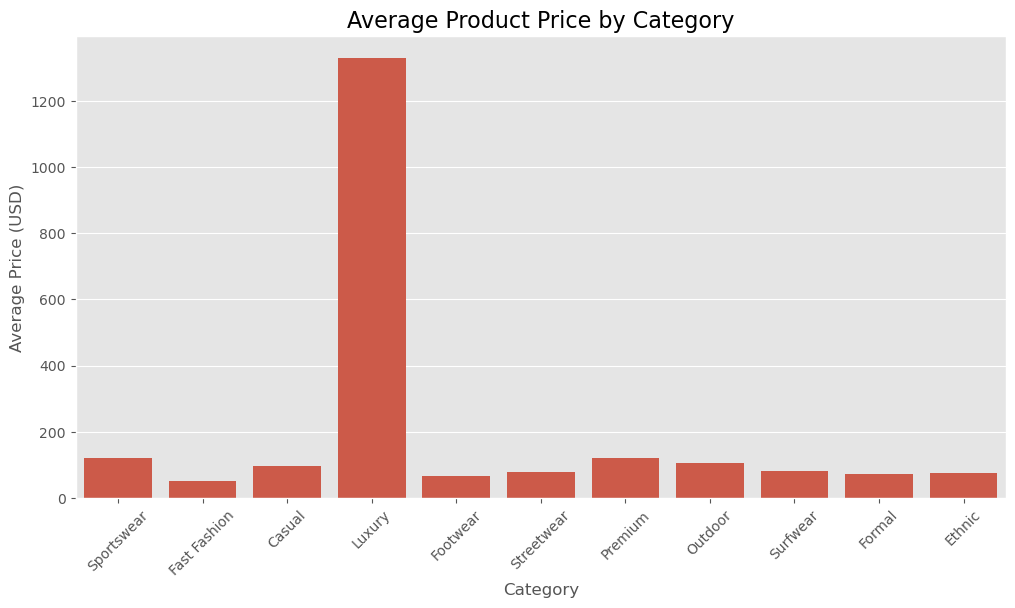

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Category",
    y="Avg_Price_USD",
    estimator="mean",
    errorbar=None
)

plt.title("Average Product Price by Category", fontsize=16)
plt.xlabel("Category")
plt.ylabel("Average Price (USD)")

plt.xticks(rotation=45)

plt.show()

# Business Insight

• Luxury brands have the highest average product prices.
• Fast Fashion brands offer more affordable products.
• Premium and Sportswear brands fall in the mid-price range.

# Sustainability Distribution

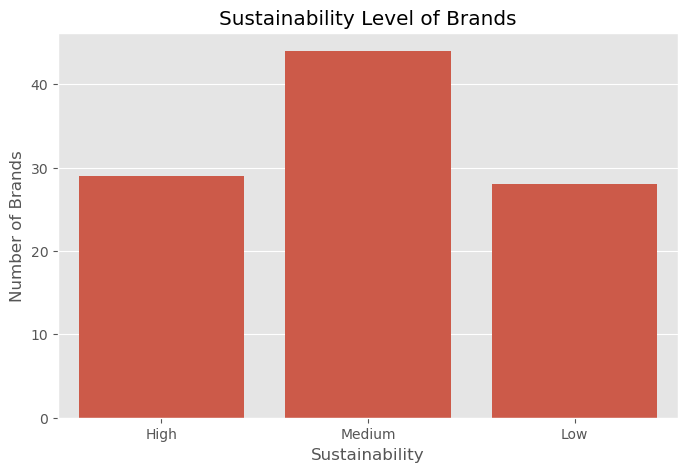

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sustainability",
    order=["High","Medium","Low"]
)

plt.title("Sustainability Level of Brands")
plt.xlabel("Sustainability")
plt.ylabel("Number of Brands")

plt.show()

# Business Insight

• Medium sustainability is the most common level.
• High sustainability brands can be attractive partners for environmentally conscious collaborations.

# Followers vs Trend Score

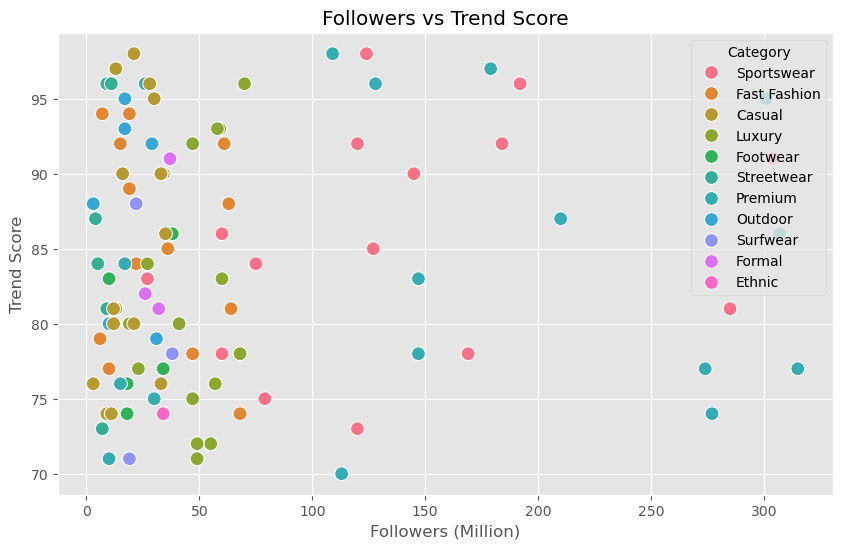

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Followers_Million",
    y="Trend_Score",
    hue="Category",
    s=100
)

plt.title("Followers vs Trend Score")
plt.xlabel("Followers (Million)")
plt.ylabel("Trend Score")

plt.show()

# Business Insight

• Brands with more followers generally tend to have higher trend scores.
• Some smaller brands also perform well, indicating strong niche popularity.

# Correlation Heatmap

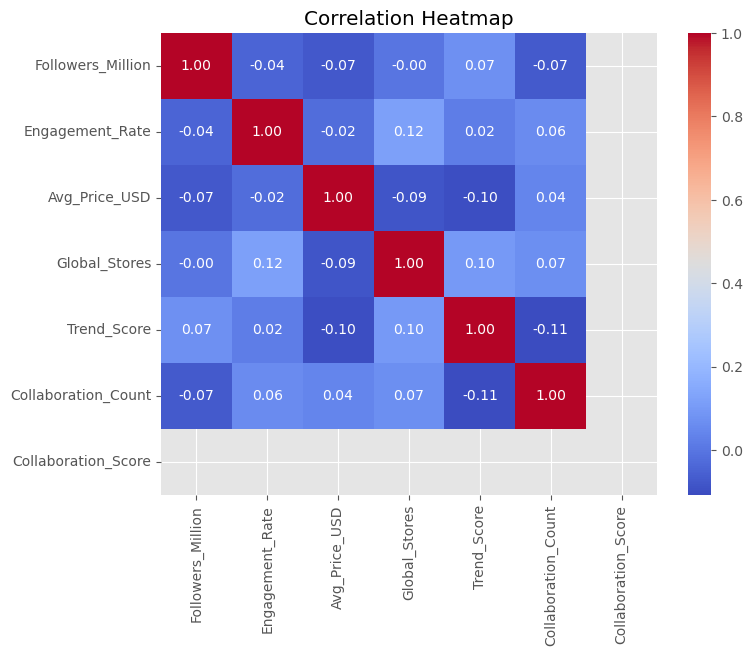

In [16]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Business Insight

• Trend Score and Followers may show positive correlation.
• Variables with stronger correlations can be used when building the recommendation score.

# Top 10 Trending Brands

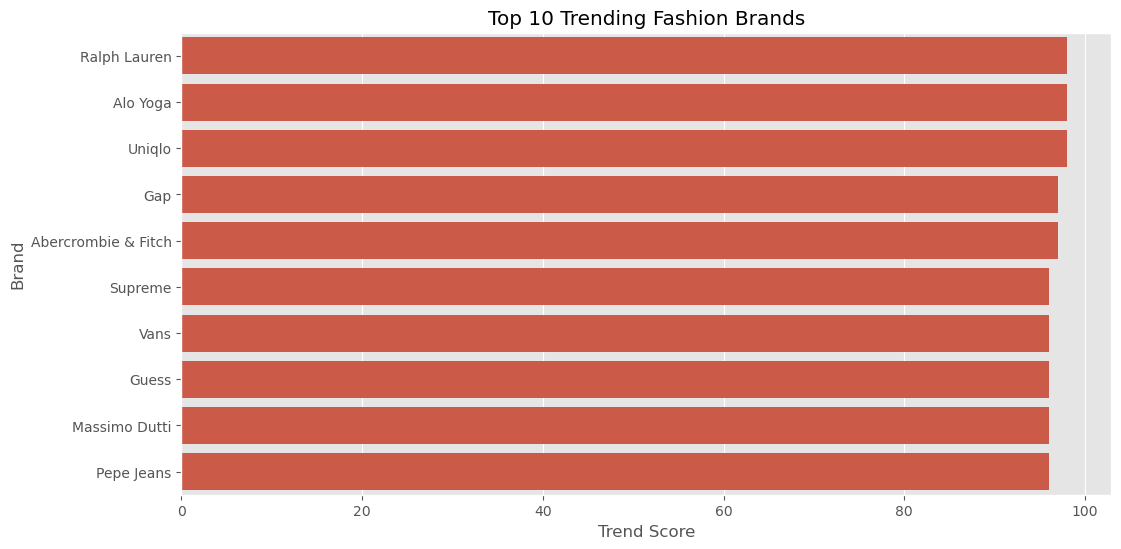

In [17]:
top_trend = df.sort_values(
    by="Trend_Score",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_trend,
    x="Trend_Score",
    y="Brand"
)

plt.title("Top 10 Trending Fashion Brands")
plt.xlabel("Trend Score")
plt.ylabel("Brand")

plt.show()

# Business Insight

• Brands with the highest trend scores are ideal candidates for strategic collaborations.
• High trend score combined with good engagement makes a brand more influential.